In [ ]:
 # scikit baata confusion matrix ra classification report

In [3]:
from tensorflow.keras.layers import Conv2D

In [2]:
test = "/content/drive/MyDrive/AI&ML/FruitinAmazon/FruitinAmazon/test"
train = "/content/drive/MyDrive/AI&ML/FruitinAmazon/FruitinAmazon/train"

In [4]:
filters = 32
kernel_size = (3, 3)
layer = Conv2D(filters, kernel_size, strides=(1,1), padding="valid", activation=None, use_bias=True,
kernel_initializer="glorot_uniform")

In [5]:
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D
max_pool = MaxPooling2D(pool_size=(2,2), strides=None, padding="valid")
avg_pool = AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

In [6]:
import tensorflow as tf
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Sample from pg 8 (ENd to End CNN model)

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9611 - loss: 0.1293 - val_accuracy: 0.9863 - val_loss: 0.0423
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9870 - loss: 0.0415 - val_accuracy: 0.9850 - val_loss: 0.0463
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9910 - loss: 0.0293 - val_accuracy: 0.9894 - val_loss: 0.0332
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9935 - loss: 0.0194 - val_accuracy: 0.9876 - val_loss: 0.0411
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9953 - loss: 0.0149 - val_accuracy: 0.9899 - val_loss: 0.0326
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9899 - loss: 0.0326
Test accuracy: 0.9899
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([

    # Convolutional Layer 1
    Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', input_shape=(128,128,3)),

    # Activation
    tf.keras.layers.ReLU(),

    # Pooling Layer 1
    MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional Layer 2
    Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same'),

    # Activation
    tf.keras.layers.ReLU(),

    # Pooling Layer 2
    MaxPooling2D(pool_size=(2,2), strides=2),

    # Flatten
    Flatten(),

    # Fully Connected Layers
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,970 (8.08 MB)

 Trainable params: 2,116,970 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
callbacks = [
    ModelCheckpoint("fruit_cnn_model.h5", save_best_only=True, monitor='val_loss'),
    EarlyStopping(monitor='val_loss', patience=10)
]

print("Model compiled and callbacks are ready!")


Model compiled and callbacks are ready!


In [11]:
history = model.fit(train_ds, validation_data= val_ds, epochs = 250,callbacks= callbacks)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0839 - loss: 2.2321

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.1111 - loss: 2.1648 - val_accuracy: 0.7222 - val_loss: 1.4100
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.2344 - loss: 1.9191

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 0.2500 - loss: 1.8826 - val_accuracy: 0.7778 - val_loss: 1.3460
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step - accuracy: 0.4028 - loss: 1.6664 - val_accuracy: 0.6667 - val_loss: 1.6421
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - accuracy: 0.4583 - loss: 1.4513 - val_accuracy: 0.5556 - val_loss: 1.3907
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6146 - loss: 1.1494

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.6250 - loss: 1.1732 - val_accuracy: 0.7778 - val_loss: 0.9839
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 0.6667 - loss: 0.9794 - val_accuracy: 0.4444 - val_loss: 1.2945
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7309 - loss: 0.8102

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 0.7083 - loss: 0.8423 - val_accuracy: 0.8333 - val_loss: 0.8459
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 0.8194 - loss: 0.6989 - val_accuracy: 0.6667 - val_loss: 0.8509
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8605 - loss: 0.4700

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9444 - val_loss: 0.1465
Epoch 30/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 1.0000 - loss: 0.0013

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 366ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.1321
Epoch 31/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 1.0000 - loss: 0.0012

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 538ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.1214
Epoch 32/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 1.0000 - loss: 0.0010    

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.1149
Epoch 33/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 1.0000 - loss: 0.0011

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 0.1135
Epoch 34/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 0.1155
Epoch 35/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 1.0000 - loss: 9.4308e-04 - val_accuracy: 1.0000 - val_loss: 0.1198
Epoch 36/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step - accuracy: 1.0000 - loss: 8.6691e-04 - val_accuracy: 1.0000 - val_loss: 0.1241
Epoch 37/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step - accuracy: 1.0000 - loss: 8.1182e-04 - val_accuracy: 1.0000 - val_loss: 0.1309
Epoch 38/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - accuracy: 1.0000 - loss: 7.6056e-04 - val_accuracy: 0.8889 - val_loss: 0.1373
Epoch 39/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - accuracy: 1.0000 - loss: 7.3581e-04 - val_accuracy: 0.8889 - val_loss: 0.1411
Epoch 40/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 531ms/step - accuracy: 1.0000 - loss: 7.1253e-04 - val_a

In [12]:
# Evaluate on test data
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

test_loss, test_acc = model.evaluate(val_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9444 - loss: 0.1336
Test Loss: 0.1336
Test Accuracy: 0.9444


In [13]:
model.save('saved_model.h5')

In [14]:
from tensorflow.keras.models import load_model
loaded_model = tf.keras.models.load_model('saved_model.h5')

print(f"Loaded Model Test Accuracy: {test_acc:.4f}")

Loaded Model Test Accuracy: 0.9444


In [15]:
# Load the saved model
loaded_model = load_model("saved_model.h5")
print("Model loaded successfully!")

# Compile the loaded model to properly build metrics
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Create the test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False # Test data should not be shuffled
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Re-evaluate on test set
test_loss, test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model Test Loss: {test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {test_acc:.4f}")

Model loaded successfully!
Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.7333 - loss: 1.5124
Loaded Model Test Loss: 1.5124
Loaded Model Test Accuracy: 0.7333


Classes: ['acai', 'pupunha', 'cupuacu', 'graviola', 'guarana', 'tucuma']


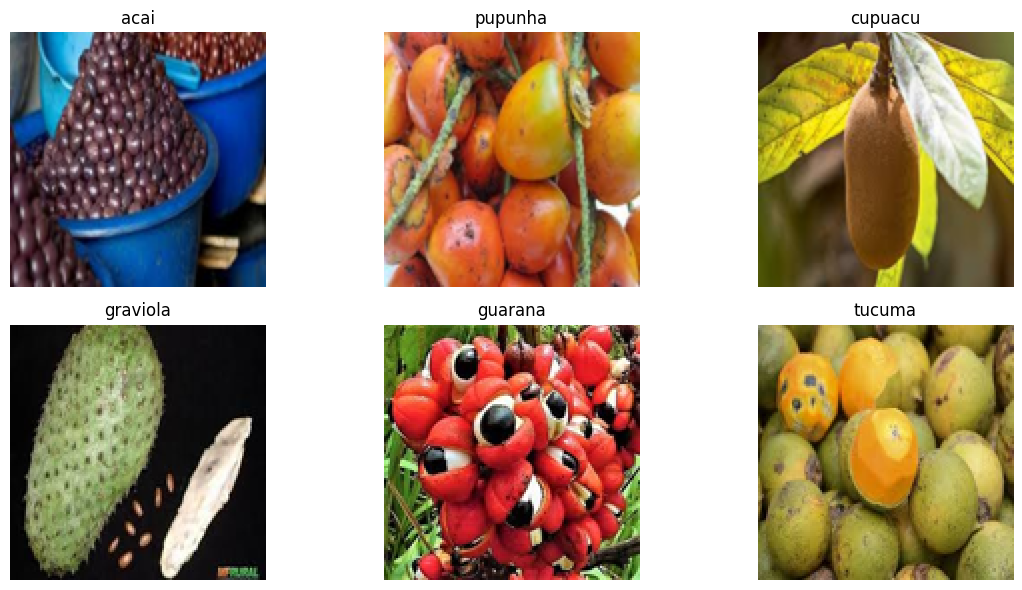

In [16]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Get class names
classes = os.listdir(train)
print("Classes:", classes)

# Select one random image per class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path).resize((img_height, img_width))
    images.append(img)
    labels.append(cls)

# Plot images (2 rows grid)
cols = len(images) // 2 + len(images) % 2

plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, cols, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
import numpy as np

# Convert list of PIL Images to a NumPy array and normalize
images_np = np.array([np.array(img) for img in images])
images_normalized = images_np / 255.0

predictions = loaded_model.predict(images_normalized)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


In [18]:
import numpy as np

predicted_labels = np.argmax(predictions, axis=1)
true_labels = labels

In [19]:
import numpy as np
from sklearn.metrics import classification_report

# Lists to store true labels and predictions
y_true = []
y_pred = []

# Loop through test dataset
for images, labels in test_ds:
    preds = loaded_model.predict(images)  # predicted probabilities
    preds = np.argmax(preds, axis=1)      # convert to class labels

    y_true.extend(labels.numpy())         # actual labels
    y_pred.extend(preds)                  # predicted labels

# Print Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     pupunha       0.44      0.80      0.57         5
     cupuacu       0.71      1.00      0.83         5
    graviola       1.00      0.60      0.75         5
     guarana       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.83      0.73      0.74        30
weighted avg       0.83      0.73      0.74        30



***WEEK6***

In [20]:
test_dir = "/content/drive/MyDrive/AI&ML/FruitinAmazon/FruitinAmazon/test"
train_dir = "/content/drive/MyDrive/AI&ML/FruitinAmazon/FruitinAmazon/train"

In [21]:
import os
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Generating the Train and Val Dataset

In [22]:
image_size = (128,128)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split = 0.2,
    subset = "both",
    seed = 1337,
    image_size = image_size,
    batch_size = batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [23]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.layers import BatchNormalization, Dropout

model = Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Data Augmentation + Rescaling
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    # Dense Layers
    Flatten(),
    Dense(256),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

dropout is only done dureing training

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.1534 - loss: 2.3975

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 996ms/step - accuracy: 0.1944 - loss: 2.2481 - val_accuracy: 0.1667 - val_loss: 1.8963
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 781ms/step - accuracy: 0.5556 - loss: 1.2249 - val_accuracy: 0.2222 - val_loss: 1.7131
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 863ms/step - accuracy: 0.6528 - loss: 0.8074 - val_accuracy: 0.0556 - val_loss: 2.0583
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 935ms/step - accuracy: 0.7222 - loss: 0.8555 - val_accuracy: 0.1111 - val_loss: 2.1005
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 790ms/step - accuracy: 0.7500 - loss: 0.6671 - val_accuracy: 0.3889 - val_loss: 2.0072
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7222 - loss: 0.8189 - val_accuracy: 0.2222 - val_loss: 2.0440
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 794ms/step - accuracy: 0.6528 - loss: 0.8850 - val_accuracy: 0.2778 - val_loss: 2.1226
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7500 - loss: 0.6174 - val_accuracy: 0.2778 - val_loss: 2.1162
Epoch 9/3

In [27]:
test_loss, test_acc = model.evaluate(val_ds)
print("Validation Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.2222 - loss: 2.3951
Validation Accuracy: 0.2222222238779068


In [28]:
model.save("cnn_fruit_model.h5")

from tensorflow.keras.models import load_model
loaded_model = load_model("cnn_fruit_model.h5")

loaded_model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step - accuracy: 0.2222 - loss: 2.3951


[2.395111322402954, 0.2222222238779068]

est for class Imbalace

In [29]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg',
                                                                               '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [30]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.22      1.00      0.36         4
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    predicted_classes = np.argmax(preds, axis=1)

    print("Predicted:", predicted_classes[:10])
    print("Actual   :", labels.numpy()[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step
Predicted: [1 1 1 1 1 1 1 1 1 1]
Actual   : [4 4 1 5 1 0 1 5 3 0]


Transfer Learning Task2

In [31]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [32]:
for layer in base_model.layers:
    layer.trainable = False

In [36]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_names), activation='softmax')(x) # Apply the Dense layer to 'x'

model_vgg = Model(inputs=base_model.input, outputs=outputs)

In [37]:
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.1111 - loss: 18.6905 - val_accuracy: 0.3333 - val_loss: 5.9165
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.3472 - loss: 7.7021 - val_accuracy: 0.4444 - val_loss: 5.0336
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.4444 - loss: 6.4031 - val_accuracy: 0.4444 - val_loss: 5.1909
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.6111 - loss: 4.4862 - val_accuracy: 0.5000 - val_loss: 5.1889
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.6806 - loss: 2.7277 - val_accuracy: 0.5556 - val_loss: 5.3863
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.8056 - loss: 1.3826 - val_accuracy: 0.6111 - val_loss: 5.4132
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.8611 - loss: 1.2823 - val_accuracy: 0.6667 - val_loss: 5.2193
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.8472 - loss: 1.0625 - val_accuracy: 0.6667 - val_loss: 5.3262
Epoch 9

In [39]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.00      0.00      0.00         4
    graviola       0.25      1.00      0.40         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.17      0.20      0.18         5

    accuracy                           0.11        18
   macro avg       0.07      0.20      0.10        18
weighted avg       0.06      0.11      0.07        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


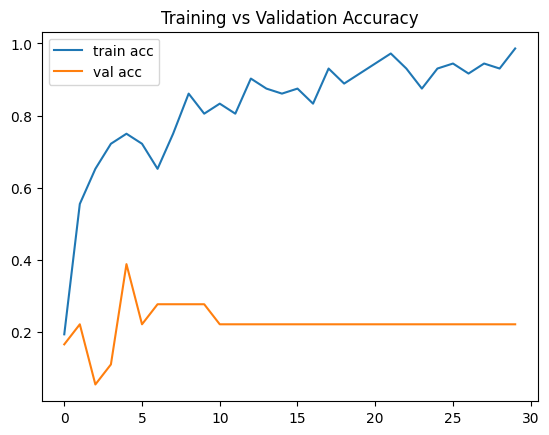

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()